### Business Problem: Optimizing Loan Portfolio Profitability While Minimizing Risk Exposure
Background:
A financial institution wants to grow its loan portfolio by approving more applications without significantly increasing its default risk. Historically, overly cautious approval strategies have led to lost revenue opportunities, while lenient strategies have increased default rates and write-offs.

#### Objective:
Use predictive modeling to identify applicants who are both **likely to repay their loans and profitable to approve**, balancing approval rates with financial risk and expected returns.

#### Key Questions to Address:
##### I] Risk Assessment (Regression Task)

1) What is the predicted RiskScore for a new applicant, indicating the likelihood of default?

2) How does this score correlate with key variables like credit history, debt-to-income ratio, or loan purpose?

##### II] Loan Approval (Classification Task)

1) Should this applicant be approved or denied for a loan based on their financial profile?

##### Strategic Decisioning

1) How can we segment applicants (e.g., low-risk/high-value, high-risk/low-value) to refine lending strategies?

2) What threshold on the RiskScore corresponds to optimal approval criteria (balancing profit vs. risk)?

3) Can we dynamically adjust interest rates based on predicted risk and expected loss?

### Task 2: Loan Approval Prediction

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

In [2]:
# Reading the dataset
df = pd.read_csv("Loan.csv")

In [ ]:
# df[['TotalDebtToIncomeRatio', 'DebtToIncomeRatio','MonthlyDebtPayments', 'MonthlyIncome', 'AnnualIncome']].head()
# df[['LoanAmount', 'LoanDuration','BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'MonthlyIncome', 'Monthly_LoanToIncomeRatio']].head()


,TotalAssets,TotalLiabilities,NetWorth
0,146111,19183,126928
1,53204,9595,43609
2,25176,128874,5205
3,104822,5370,99452
4,244305,17286,227019


### Calculated Metrics
-----------------
P = Loan Amount

r = Interest Rate (NOT Base Interest Rate)

n = Loan Duration in Months

**Monthly Loan Amount** = P * r * (1 + r)^n / ((1 + r)^n - 1)

-----------------

**Net worth** = Total Assets - Total Liabilities

-----------------

**AnnualIncome** = MonthlyIncome * 12

-----------------

**DebtToIncomeRatio** = MonthlyDebtPayment / MonthlyIncome

-----------------

**InterestRate** = BaseInterestRate + Margin

-----------------

**Monthly_LoanToIncomeRatio** = MonthlyLoanAmount / MonthlyIncome



In [22]:
# Getting a preview of the dataset
df[df['LoanApproved']==0][['RiskScore']].describe()

,RiskScore
count,15220.000000
mean,54.106307
std,5.301985
min,38.000000
25%,50.000000
50%,54.000000
75%,57.000000
max,84.000000


In [56]:
df[[ 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
'LengthOfCreditHistory',
'PaymentHistory',
'UtilityBillsPaymentHistory'
 ]].head()

,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,LengthOfCreditHistory,PaymentHistory,UtilityBillsPaymentHistory
0,0.354418,1,2,9,29,0.724972
1,0.087827,5,3,9,21,0.935132
2,0.137414,2,0,22,20,0.872241
3,0.267587,2,1,10,27,0.896155
4,0.320535,0,0,27,26,0.941369


In [57]:
df['HomeOwnershipStatus'].unique()

array(['Own', 'Mortgage', 'Rent', 'Other'], dtype=object)

In [59]:
df.columns.tolist()

['ApplicationDate',
 'Age',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'LoanApproved',
 'RiskScore',
 'DebtToIncomeRatio',
 'Monthly_LoanToIncomeRatio']

In [60]:
df.shape

(20000, 26)

In [ ]:
# Dropping unnecessary columns
df.drop(columns=['DebtToIncomeRatio'], axis=1, inplace=True)

In [ ]:
# Calculate Debt to Income Ratio (using monthly income and debt amounts)
df['DebtToIncomeRatio'] = df['MonthlyDebtPayments']/df['MonthlyIncome']
df['Monthly_LoanToIncomeRatio'] = df['MonthlyLoanPayment']/df['MonthlyIncome']

In [ ]:
# Converting the date column to datetime
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

# Extracting Year and Month from Application Date (this will be useful to perform trend analysis)
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month

In [ ]:
df[['ApplicationDate', 'ApplicationYear', 'ApplicationMonth']].head()

,ApplicationDate,ApplicationYear,ApplicationMonth
0,2018-01-01,2018,1
1,2018-01-02,2018,1
2,2018-01-03,2018,1
3,2018-01-04,2018,1
4,2018-01-05,2018,1


In [ ]:
# Revising the Application date column
# df = df[~df['ApplicationYear'].isin([2067, 2068, 2069, 2070, 2071, 2072])]

conditions = [
    ((df['ApplicationYear'] >= 2025) & (df['ApplicationYear'] <= 2031)) | (df['ApplicationYear'] == 2018),
    ((df['ApplicationYear'] >= 2032) & (df['ApplicationYear'] <= 2038)) | (df['ApplicationYear'] == 2019),
    ((df['ApplicationYear'] >= 2039) & (df['ApplicationYear'] <= 2045)) | (df['ApplicationYear'] == 2020),
    ((df['ApplicationYear'] >= 2046) & (df['ApplicationYear'] <= 2052)) | (df['ApplicationYear'] == 2021),
    ((df['ApplicationYear'] >= 2053) & (df['ApplicationYear'] <= 2059)) | (df['ApplicationYear'] == 2022),
    ((df['ApplicationYear'] >= 2060) & (df['ApplicationYear'] <= 2066)) | (df['ApplicationYear'] == 2023),
    (df['ApplicationYear'] >= 2067) | (df['ApplicationYear'] == 2024)
    ]

replacemet_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

df['ApplicationYear'] = np.select(conditions, replacemet_years)

In [ ]:
df['ApplicationYear'].value_counts().sort_index()

ApplicationYear
2018    2921
2019    2922
2020    2923
2021    2922
2022    2921
2023    2922
2024    2469
Name: count, dtype: int64

In [ ]:
# Dropping the Application date column
df.drop(columns = ['ApplicationDate'], inplace=True)

In [ ]:
# Grouping the columns by the datatype
col = df.columns.to_series().groupby(df.dtypes).groups

col2 = {k.name: v for k, v in col.items()}

In [59]:
col2

{'int32': Index(['ApplicationYear', 'ApplicationMonth'], dtype='object'),
 'int64': Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
        'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
        'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
        'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory',
        'LengthOfCreditHistory', 'SavingsAccountBalance',
        'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
        'JobTenure', 'NetWorth', 'LoanApproved'],
       dtype='object'),
 'float64': Index(['CreditCardUtilizationRate', 'DebtToIncomeRatio', 'MonthlyIncome',
        'UtilityBillsPaymentHistory', 'BaseInterestRate', 'InterestRate',
        'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
       dtype='object'),
 'object': Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
        'HomeOwnershipStatus', 'LoanPurpose'],
       dtype='object')}

In [ ]:
# Check the trend of the loan approvals over the years


Feature Selection using heatmap

In [ ]:
#-------------------------------------------------------------
from sklearn.feature_selection import RFE, FSSearch, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

# Load the dataset
X = ... # features
y = ... # target

# Create a logistic regression model
model = LogisticRegression()

"""
Recursive Feature Elimination (RFE) is a feature selection technique that involves training a model on a subset of the features, 
and then iteratively removing the least important features one by one until we are left with the desired number of features.
"""

# Use RFE to select the top 10 features
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

# Print the selected features
print(rfe.support_)

"""
“Forward Selection”, which involves starting with an empty set of features and iteratively adding one feature at a time until the 
desired number of features is reached. At each step, the model is trained and evaluated, and the feature that results in the greatest 
improvement in performance is added to the set.
"""

# Use FSSearch to select the top 10 features
fs = FSSearch(model, scoring='accuracy')
fs.fit(X, y)

# Print the selected features
print(fs.best_idx_)


"""
Filter approach to feature selection involves using statistical tests or heuristics to select the most relevant features for a predictive model. 
The goal is to select features that are highly correlated with the target variable, as these are likely to be the most useful for prediction.
"""

# Use SelectKBest to select the top 10 features
selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(X, y)

# Print the selected features
print(selector.get_support())
#-------------------------------------------------------------

In [12]:
# Encoding
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

# Let's say these are your categorical columns
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

encoder.fit(df[categorical_cols])
df[categorical_cols] = encoder.transform(df[categorical_cols])

In [88]:
for col, categories in zip(categorical_cols, encoder.categories_):
    print(f"Mapping for '{col}':")
    for i, cat in enumerate(categories):
        print(f"  {cat} --> {i}")
    print()

Mapping for 'EmploymentStatus':
  Employed --> 0
  Self-Employed --> 1
  Unemployed --> 2

Mapping for 'EducationLevel':
  Associate --> 0
  Bachelor --> 1
  Doctorate --> 2
  High School --> 3
  Master --> 4

Mapping for 'MaritalStatus':
  Divorced --> 0
  Married --> 1
  Single --> 2
  Widowed --> 3

Mapping for 'HomeOwnershipStatus':
  Mortgage --> 0
  Other --> 1
  Own --> 2
  Rent --> 3

Mapping for 'LoanPurpose':
  Auto --> 0
  Debt Consolidation --> 1
  Education --> 2
  Home --> 3
  Other --> 4



In [87]:
df[categorical_cols]

,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,LoanPurpose
0,0.0,4.0,1.0,2.0,3.0
1,0.0,0.0,2.0,0.0,1.0
2,0.0,1.0,1.0,3.0,2.0
3,0.0,3.0,2.0,0.0,3.0
4,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...
19995,0.0,3.0,1.0,3.0,0.0
19996,0.0,0.0,1.0,3.0,1.0
19997,0.0,1.0,1.0,0.0,3.0
19998,0.0,3.0,1.0,2.0,1.0


In [13]:
# Standard Scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df)
scaled_df = scaler.transform(df)

In [26]:
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

In [25]:
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,ApplicationYear,ApplicationMonth,Index
0,45,39948,617,0.0,4.0,22,13152,48,1.0,2,...,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,2018,1,0
1,38,39709,628,0.0,0.0,15,26045,48,2.0,1,...,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,2018,1,1
2,47,40724,570,0.0,1.0,26,17627,36,1.0,2,...,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,2018,1,2
3,58,69084,545,0.0,3.0,34,37898,96,2.0,1,...,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,2018,1,3
4,37,103264,594,0.0,0.0,17,9184,36,1.0,1,...,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,2018,1,4


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
features = scaled_df.drop(columns= ['LoanApproved', 'Index'], axis = 1)
target = scaled_df['LoanApproved']

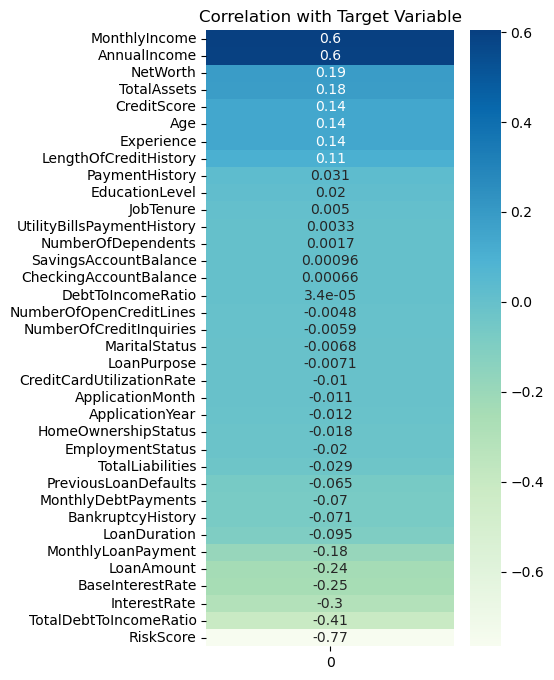

In [28]:
# Create a correlation matrix with target variable
corr_with_target = features.corrwith(target)

# Sort features by correlation with target variable
corr_with_target = corr_with_target.sort_values(ascending=False)

# Plot the heatmap
plt.figure(figsize=(4, 8))
sns.heatmap(corr_with_target.to_frame(), cmap='GnBu', annot=True)
plt.title('Correlation with Target Variable')
plt.show()

Higher the risk score, higher the interest rate
Higher credit score, lower default risk
Consumer credit risk can be measured by the five Cs: credit history, capacity to repay, capital, the loan's conditions, and associated collateral.

In [29]:
df['CreditScore'].min(), df['CreditScore'].max()

(343, 712)

In [34]:
# TotalDebtToIncomeRatio
# RiskScore
# LengthOfCreditHistory
# PreviousLoanDefaults
# DebtToIncomeRatio	
# BankruptcyHistory


df_subset = df[['RiskScore', 'TotalDebtToIncomeRatio', 'InterestRate', 'LoanAmount', 'BaseInterestRate', 'MonthlyLoanPayment', 'MonthlyIncome', 'AnnualIncome', 'NetWorth', 'TotalAssets', 'CreditScore', 'Age', 'Experience', 'LengthOfCreditHistory', 'LoanApproved']]

In [35]:
df_subset.head()

,RiskScore,TotalDebtToIncomeRatio,InterestRate,LoanAmount,BaseInterestRate,MonthlyLoanPayment,MonthlyIncome,AnnualIncome,NetWorth,TotalAssets,CreditScore,Age,Experience,LengthOfCreditHistory,LoanApproved
0,49.0,0.181077,0.227590,13152,0.199652,419.805992,3329.000000,39948,126928,146111,617,45,22,9,0
1,52.0,0.389852,0.201077,26045,0.207045,794.054238,3309.083333,39709,43609,53204,628,38,15,9,0
2,52.0,0.462157,0.212548,17627,0.217627,666.406688,3393.666667,40724,5205,25176,570,47,26,22,0
3,54.0,0.313098,0.300911,37898,0.300398,1047.506980,5757.000000,69084,99452,104822,545,58,34,10,0
4,36.0,0.070210,0.175990,9184,0.197184,330.179140,8605.333333,103264,227019,244305,594,37,17,27,1


In [39]:
df_subset.groupby(['LoanApproved']).size()

LoanApproved
0    15220
1     4780
dtype: int64

In [44]:
# Train test split
X = df_subset.drop(columns='LoanApproved', axis = 1)
y = df_subset['LoanApproved']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size= 0.3, stratify=y)
Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size= 0.5, stratify=ytemp)

encoder = StandardScaler()

encoder.fit(Xtrain)
Xtrain = encoder.transform(Xtrain)
Xval = encoder.transform(Xval)
Xtest = encoder.transform(Xtest)

In [46]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(Xtrain, ytrain)
y_val_pred = lr.predict(Xval)

# Generate a classification report
cr = classification_report(yval,y_val_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2283
           1       0.98      0.98      0.98       717

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [48]:
ypred = lr.predict(Xtest)

# Generate a classification report
cr = classification_report(ytest,ypred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2283
           1       0.99      0.99      0.99       717

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [49]:
import pickle

# save
with open('model.pkl','wb') as f:
    pickle.dump(lr,f)